# Random Forest Classification and Feature Importance

## Project Introduction

The goal of this project is to train a Random Forest classification model using the Breast Cancer Wisconsin dataset.

The project aims to predict the target class based on the available features and evaluate the model's performance.

Feature importance is also used to identify which features contribute most to the model's tree-based decisions.

This project helps us understand how Random Forest works and how feature importance can be used to interpret a machine learning model.


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report , confusion_matrix

## 1. Import Libraries

In this step, we import the libraries required for data handling, visualization, model training, and evaluation.

* **Pandas:** Used to organize and manipulate data in DataFrames.
* **Matplotlib:** Used to create charts and visualize feature importance.
* **load_breast_cancer:** Used to load the Breast Cancer Wisconsin dataset.
* **train_test_split:** Used to divide the dataset into training and testing sets.
* **RandomForestClassifier:** Used to create and train the Random Forest classification model.
* **accuracy_score:** Used to calculate the percentage of correct predictions.
* **classification_report:** Used to evaluate precision, recall, and F1-score.
* **confusion_matrix:** Used to show correct and incorrect predictions for each class.


In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data , columns=data.feature_names)
y = pd.Series(data.target , name="target")

X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [4]:
y.head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: target, dtype: int64

In [5]:
y.tail(10)

559    1
560    1
561    1
562    0
563    0
564    0
565    0
566    0
567    0
568    1
Name: target, dtype: int64

In [6]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
X.shape

(569, 30)

In [8]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [9]:
X.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

## 2. Load and Explore the Dataset

In this step, we load the Breast Cancer Wisconsin dataset and explore its structure before training the model.

* **load_breast_cancer():** Loads the dataset provided by scikit-learn.
* **X:** Contains the input features used by the model to make predictions.
* **y:** Contains the target labels that the model must predict.
* **pd.DataFrame():** Organizes the feature data into a table with named columns.
* **pd.Series():** Stores the target labels in a one-dimensional structure.
* **head():** Displays the first five rows to inspect the data.
* **info():** Displays information about the dataset, including column names, non-null values, data types, and memory usage. It helps us understand the dataset structure and identify columns that may contain missing values.
* **shape:** Shows the number of rows and columns.
* **value_counts():** Shows how many samples belong to each target class.
* **isnull().sum():** Counts the total number of missing values in X.

Exploring the dataset helps us understand the available features and check whether any data preparation is needed before training.


In [10]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 3. Splitting the Dataset

We split the dataset into training and testing sets to evaluate the model on data it has not seen during training.

* **X_train:** The input features used for training.
* **X_test:** The input features used for testing.
* **y_train:** The correct target labels for the training data.
* **y_test:** The correct target labels for the testing data.
* **test_size=0.2:** Allocates 20% of the data for testing and 80% for training.
* **random_state=42:** Makes the random split reproducible.
* **stratify=y:** Helps preserve the proportion of each target class in both sets.

This split helps us evaluate whether the model can generalize to unseen data rather than only memorizing the training examples.


In [11]:
model = RandomForestClassifier( 
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced")

model.fit(X_train , y_train)
y_prec = model.predict(X_test)
acc = accuracy_score(y_test , y_prec)
print("accuracy_score = " , acc)

print("\nClassification Report:")
print(classification_report(y_test, y_prec, target_names=data.target_names))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_prec))

accuracy_score =  0.9473684210526315

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.95      0.93        42
      benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix:
[[40  2]
 [ 4 68]]


## 4. Building and Training the Random Forest Model

We use Random Forest because it combines multiple decision trees to make classification predictions. Combining many trees can improve prediction stability compared with relying on a single tree.

The model is trained using the training data.

### Model Parameters

* **n_estimators=200:** Creates 200 decision trees. Using multiple trees helps combine their predictions, although more trees require additional computation.
* **max_depth=10:** Limits the maximum depth of each tree to help control model complexity and reduce overfitting.
* **random_state=42:** Makes the model's random processes reproducible.
* **class_weight="balanced":** Automatically adjusts class weights according to their frequencies in the training data. This can help when the classes are imbalanced.

The **fit()** method trains the model using X_train and y_train. During training, the model learns tree-based decision rules from the input features and target labels.

These parameter values are initial choices and are not guaranteed to be optimal for every dataset.


In [12]:
importance = pd.DataFrame({
    "Feature" : X.columns,
    "importance" : model.feature_importances_

})

importance = importance.sort_values(
    by ="importance",
    ascending=False

)
print(importance.head(10))

                 Feature  importance
22       worst perimeter    0.152042
23            worst area    0.118750
27  worst concave points    0.112023
7    mean concave points    0.106395
20          worst radius    0.071330
6         mean concavity    0.060791
2         mean perimeter    0.047528
3              mean area    0.044914
0            mean radius    0.043592
26       worst concavity    0.038117


## 5. Feature Importance Analysis

Feature importance is used to identify which input features contribute most to the Random Forest model's tree-based decisions.

* **model.feature_importances_:** Returns the model's impurity-based importance score for each feature after training.
* **X.columns:** Provides the names of the input features.
* **pd.DataFrame():** Combines feature names and importance scores into one table.
* **sort_values():** Sorts the features according to their importance scores.
* **by="Importance":** Specifies the column used for sorting.
* **ascending=False:** Sorts the scores from highest to lowest.
* **head(10):** Displays the ten features with the highest scores.

The default importance measure in scikit-learn's Random Forest is based on the reduction in node impurity across the trees.

A higher score means that a feature contributed more to impurity reduction within the trained forest, according to this measure. It does not mean that the feature causes the target outcome or directly accounts for the same percentage of prediction accuracy.

Feature importance helps us interpret the model and identify features that may deserve further investigation.


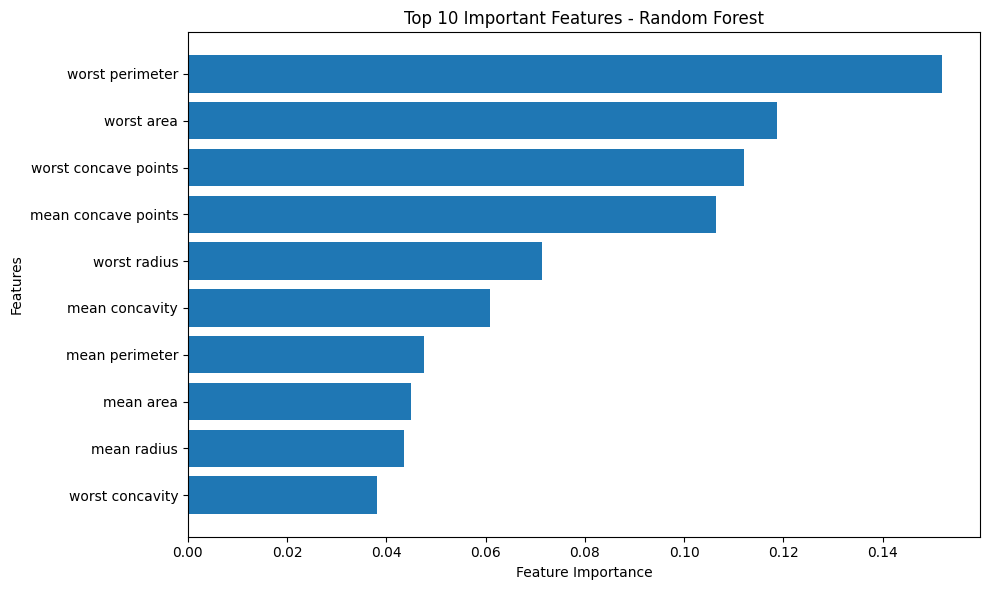

In [13]:
top_features = importance.head(10).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")

plt.tight_layout()
plt.show()

## 6. Visualizing Feature Importance

We create a horizontal bar chart to make the feature importance scores easier to compare.

* **top_features:** Stores the ten most important features.
* **plt.figure(figsize=(10, 6)):** Creates a figure with enough space to display the feature names.
* **plt.barh():** Draws horizontal bars, with feature names on the vertical axis and importance scores on the horizontal axis.
* **xlabel():** Labels the horizontal axis.
* **ylabel():** Labels the vertical axis.
* **title():** Adds a descriptive chart title.
* **tight_layout():** Adjusts the spacing to reduce overlap between chart elements.
* **show():** Displays the chart.

The length of each bar represents the feature's importance score. This visualization helps us quickly identify and compare the features with the highest scores.


## 7. Conclusion

In this project, we trained and evaluated a Random Forest classification model using the Breast Cancer Wisconsin dataset.

The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

Feature importance was used to identify the features that contributed most to impurity reduction in the trained model. A horizontal bar chart was created to visualize the top ten features.

This project demonstrates how Random Forest can be used for classification and how feature importance can help interpret its decisions. The results should be evaluated carefully, and feature importance should not be interpreted as proof of causation or as a substitute for model evaluation.
